<a href="https://colab.research.google.com/github/NathanHonn/Computer-Vision-for-Instrument-Detection-in-Microsurgical-Venous-Anastomosis/blob/main/Computer_Vision_for_Instrument_Detection_in_Microsurgical_Venous_Anastomosis_Colab_File.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!pip3 install triton

In [ ]:
!pip3 install -U xformers --index-url https://download.pytorch.org/whl/cu128

Looking in indexes: https://download.pytorch.org/whl/cu128


In [ ]:
!pip install rfdetr-seg-intermediate

In [ ]:
import zipfile
import os
from google.colab import files
import json
import numpy as np
from tqdm import tqdm
from PIL import Image
from pycocotools.coco import COCO
from pycocotools.cocoeval import COCOeval
import zipfile

print("Please select the zip file to upload and unzip:")
uploaded = files.upload()

if not uploaded:
    print("No file was uploaded. Please upload a zip file to continue.")
else:
    zip_file_path = next(iter(uploaded))

    extracted_dir = './Extracted Files'

    os.makedirs(extracted_dir, exist_ok=True)

    try:
        with zipfile.ZipFile(zip_file_path, 'r') as zip_ref:
            zip_ref.extractall(extracted_dir)
        print(f"Successfully unzipped '{zip_file_path}' to '{extracted_dir}'")
    except zipfile.BadZipFile:
        print(f"Error: '{zip_file_path}' is not a valid zip file.")
    except FileNotFoundError:
        print(f"Error: Zip file '{zip_file_path}' not found. Please ensure it's uploaded correctly.")
    except Exception as e:
        print(f"An unexpected error occurred: {e}")


Please select the zip file to upload and unzip:


Saving main.v31-640--extra-image--correct-dataset.coco.zip to main.v31-640--extra-image--correct-dataset.coco.zip
Successfully unzipped 'main.v31-640--extra-image--correct-dataset.coco.zip' to './Extracted Files'


In [ ]:
!pip uninstall -y tensorflow

Found existing installation: tensorflow 2.19.0
Uninstalling tensorflow-2.19.0:
  Successfully uninstalled tensorflow-2.19.0


In [ ]:
!pip install faster-coco-eval[extra]

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 588.1/588.1 kB 35.6 MB/s eta 0:00:00


In [ ]:
os.environ["USE_TF"] = "0"
os.environ["USE_TORCH"] = "1"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "3"
os.environ["TF_ENABLE_ONEDNN_OPTS"] = "0"
os.environ["WANDB_API_KEY"]="Insert your api key"

from rfdetr import RFDETRMedium

Resolution=640
model = RFDETRMedium(resolution=Resolution)

# Create the output directory if it doesn't exist
os.makedirs("./Model Output", exist_ok=True)

model.train(
    dataset_dir="./Extracted Files",
    epochs=50,
    output_dir="./Model Output",
    early_stopping=True,
    batch_size=6,
    early_stopping_patience=4,
    lr=5E-5,
    wandb=True,
    do_benchmark=False,
    num_workers=12,
    resolution=Resolution
)

rf-detr-medium.pth: 100%|██████████| 386M/386M [00:26<00:00, 15.4MiB/s]


Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights
TensorBoard logging initialized. To monitor logs, use 'tensorboard --logdir /content/Model Output' and open http://localhost:6006/ in browser.


wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from WANDB_API_KEY.
wandb: Currently logged in as: immaengineer2 (immaengineer2-cleveland-clinic) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


W&B logging initialized. To monitor logs, open https://wandb.ai/immaengineer2-cleveland-clinic/uncategorized/runs/9sg5kdxe.
Not using distributed mode
git:
  sha: N/A, status: clean, branch: N/A

Namespace(num_classes=9, grad_accum_steps=4, amp=True, lr=5e-05, lr_encoder=0.00015, batch_size=6, weight_decay=0.0001, epochs=50, lr_drop=100, clip_max_norm=0.1, lr_vit_layer_decay=0.8, lr_component_decay=0.7, do_benchmark=False, dropout=0, drop_path=0.0, drop_mode='standard', drop_schedule='constant', cutoff_epoch=0, pretrained_encoder=None, pretrain_weights='rf-detr-medium.pth', pretrain_exclude_keys=None, pretrain_keys_modify_to_load=None, pretrained_distiller=None, encoder='dinov2_windowed_small', vit_encoder_num_layers=12, window_block_indexes=None, position_embedding='sine', out_feature_indexes=[3, 6, 9, 12], freeze_encoder=False, layer_norm=True, rms_norm=False, backbone_lora=False, force_no_pretrain=False, dec_layers=4, dim_feedforward=2048, hidden_dim=256, sa_nheads=8, ca_nheads=16, 

Epoch: [0]  [  0/135]  eta: 0:19:33  lr: 0.000050  class_error: 71.36  loss: 12.0156 (12.0156)  loss_ce: 1.0003 (1.0003)  loss_bbox: 0.5014 (0.5014)  loss_giou: 0.7407 (0.7407)  loss_ce_0: 0.9375 (0.9375)  loss_bbox_0: 0.6966 (0.6966)  loss_giou_0: 0.8851 (0.8851)  loss_ce_1: 0.9618 (0.9618)  loss_bbox_1: 0.5957 (0.5957)  loss_giou_1: 0.8121 (0.8121)  loss_ce_2: 0.9839 (0.9839)  loss_bbox_2: 0.5413 (0.5413)  loss_giou_2: 0.7678 (0.7678)  loss_ce_enc: 0.8824 (0.8824)  loss_bbox_enc: 0.7477 (0.7477)  loss_giou_enc: 0.9613 (0.9613)  loss_ce_unscaled: 1.0003 (1.0003)  class_error_unscaled: 71.3584 (71.3584)  loss_bbox_unscaled: 0.1003 (0.1003)  loss_giou_unscaled: 0.3704 (0.3704)  cardinality_error_unscaled: 3875.5000 (3875.5000)  loss_ce_0_unscaled: 0.9375 (0.9375)  loss_bbox_0_unscaled: 0.1393 (0.1393)  loss_giou_0_unscaled: 0.4425 (0.4425)  cardinality_error_0_unscaled: 3884.5000 (3884.5000)  loss_ce_1_unscaled: 0.9618 (0.9618)  loss_bbox_1_unscaled: 0.1191 (0.1191)  loss_giou_1_unscale

Test:  [ 0/18]  eta: 0:00:17  class_error: 0.00  loss: 6.2852 (6.2852)  loss_ce: 0.7461 (0.7461)  loss_bbox: 0.1931 (0.1931)  loss_giou: 0.2211 (0.2211)  loss_ce_0: 0.8164 (0.8164)  loss_bbox_0: 0.2271 (0.2271)  loss_giou_0: 0.2542 (0.2542)  loss_ce_1: 0.7578 (0.7578)  loss_bbox_1: 0.1957 (0.1957)  loss_giou_1: 0.2275 (0.2275)  loss_ce_2: 0.7305 (0.7305)  loss_bbox_2: 0.1931 (0.1931)  loss_giou_2: 0.2219 (0.2219)  loss_ce_enc: 0.8398 (0.8398)  loss_bbox_enc: 0.3325 (0.3325)  loss_giou_enc: 0.3283 (0.3283)  loss_ce_unscaled: 0.7461 (0.7461)  class_error_unscaled: 0.0000 (0.0000)  loss_bbox_unscaled: 0.0386 (0.0386)  loss_giou_unscaled: 0.1106 (0.1106)  cardinality_error_unscaled: 254.0000 (254.0000)  loss_ce_0_unscaled: 0.8164 (0.8164)  loss_bbox_0_unscaled: 0.0454 (0.0454)  loss_giou_0_unscaled: 0.1271 (0.1271)  cardinality_error_0_unscaled: 232.0000 (232.0000)  loss_ce_1_unscaled: 0.7578 (0.7578)  loss_bbox_1_unscaled: 0.0391 (0.0391)  loss_giou_1_unscaled: 0.1138 (0.1138)  cardinalit

Loss/Test,█▆▄▅▄▃▃▄▂▃▃▃▃▁▂▃▂▂▃▂▁▁▁▂▂▂
Loss/Train,█▆▅▄▄▃▃▃▃▃▃▂▂▂▂▂▂▂▁▂▁▁▁▁▁▁
Metrics/Base/AP50,▁▃▅▅▅▆▆▆▇▇▇▇▇▇▇▇█▇▇███████
Metrics/Base/AP50_90,▁▂▄▅▅▆▆▆▇▆▆▇▇█▇▇▇▇▇███████
Metrics/Base/AR50_90,▁▄▇▄▇▅▃▆▅▄▄▄▃▇▄▄▃▆▆▆▆██▆▄▅
Metrics/EMA/AP50,▁▃▄▅▅▆▆▆▇▇▇▇▇▇████████████
Metrics/EMA/AP50_90,▁▂▄▅▅▆▆▆▆▇▇▇▇▇▇▇██████████
Metrics/EMA/AR50_90,▁▅▅▇█▇▆▅▆▅▅▆▅▆▆▅▅▇▇▇▇▇▇▇▇▇
epoch,▁▁▂▂▂▂▃▃▃▄▄▄▄▅▅▅▅▆▆▆▇▇▇▇██
Loss/Test,5.65565
Loss/Train,4.55329


In [ ]:
output_dir = "./Model Output"
dataset_dir = "./Extracted Files"

def test(split_type="test", confidence_threshold=0.0001):
    # Runs on the either the test or validation data, shows the result

    match split_type: # Checks to make sure what the user wants to test on is a valid part of the data.
        case "test":
            split="test"
        case "val" | "valid":
            split="valid"
        case _:
            raise ValueError("Invalid split type")

    model.pretrain_weights = os.path.join(output_dir, "checkpoint_best_total.pth")

    os.makedirs(output_dir, exist_ok=True)

    split = split
    ann_file = os.path.join(dataset_dir, split, "_annotations.coco.json")
    img_dir = os.path.join(dataset_dir, split)

    # Load ground truth
    coco_yi = COCO(ann_file)
    category_names = {cat['id']: cat['name'] for cat in coco_yi.loadCats(coco_yi.getCatIds())}
    category_IDs = coco_yi.getCatIds()

    # Generate predictions
    predictions = []
    for img_id in tqdm(coco_yi.getImgIds(), desc="Running inference"):
        img_info = coco_yi.loadImgs(img_id)[0]
        image = Image.open(os.path.join(img_dir, img_info['file_name'])).convert("RGB")

        result = model.predict(image, threshold=confidence_threshold,resolution=Resolution)

        for box, mask, confidence, class_id, tracker_id, data in result:
            x1, y1, x2, y2 = box
            predictions.append({
                'image_id': img_id,
                'category_id': int(class_id),
                'bbox': [float(x1), float(y1), float(x2 - x1), float(y2 - y1)],
                'score': float(confidence)
            })

    print(f"Generated {len(predictions)} predictions")

    # Save and evaluate
    with open(os.path.join(output_dir, "predictions.json"), 'w') as f:
        json.dump(predictions, f)

    coco_dt = coco_yi.loadRes(os.path.join(output_dir, "predictions.json"))
    coco_eval = COCOeval(coco_yi, coco_dt, 'bbox')
    coco_eval.evaluate()
    coco_eval.accumulate()
    coco_eval.summarize()

    precisions = coco_eval.eval['precision']
    recalls = coco_eval.eval['recall']

    print("\n" + "=" * 70)
    print("PER-CLASS METRICS")
    print("=" * 70)
    print(f"{'Class':<30} {'AP':>8} {'AP50':>8} {'AP75':>8} {'AR':>8}")
    print("-" * 70)

    for idx, ID in enumerate(category_IDs):
        name = category_names[ID]
        p = precisions[:, :, idx, 0, 2]
        ap = np.mean(p[p > -1]) if (p > -1).any() else 0.0
        ap50 = np.mean(precisions[0, :, idx, 0, 2][precisions[0, :, idx, 0, 2] > -1]) if (precisions[0, :, idx, 0, 2] > -1).any() else 0.0
        ap75 = np.mean(precisions[5, :, idx, 0, 2][precisions[5, :, idx, 0, 2] > -1]) if (precisions[5, :, idx, 0, 2] > -1).any() else 0.0
        r = recalls[:, idx, 0, 2]
        ar = np.mean(r[r > -1]) if (r > -1).any() else 0.0

        print(f"{name:<30} {ap * 100:>7.1f}% {ap50 * 100:>7.1f}% {ap75 * 100:>7.1f}% {ar * 100:>7.1f}%")

    print("=" * 70)

In [ ]:
# Run on Val

test(split_type="val")

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!


Running inference: 100%|██████████| 105/105 [00:03<00:00, 27.50it/s]


Generated 31500 predictions
Loading and preparing results...
DONE (t=0.52s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=1.09s).
Accumulating evaluation results...
DONE (t=0.25s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.714
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.875
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.787
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.060
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.512
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.740
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.558
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.808
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.828
 Average Recall     (AR) @[ IoU=0.50:0.9

In [ ]:
# Run on Test

test(split_type="test")

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!


Running inference: 100%|██████████| 42/42 [00:01<00:00, 26.89it/s]


Generated 12600 predictions
Loading and preparing results...
DONE (t=0.06s)
creating index...
index created!
Running per image evaluation...
Evaluate annotation type *bbox*
DONE (t=0.34s).
Accumulating evaluation results...
DONE (t=0.12s).
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.719
 Average Precision  (AP) @[ IoU=0.50      | area=   all | maxDets=100 ] = 0.913
 Average Precision  (AP) @[ IoU=0.75      | area=   all | maxDets=100 ] = 0.794
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= small | maxDets=100 ] = 0.264
 Average Precision  (AP) @[ IoU=0.50:0.95 | area=medium | maxDets=100 ] = 0.461
 Average Precision  (AP) @[ IoU=0.50:0.95 | area= large | maxDets=100 ] = 0.798
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=  1 ] = 0.696
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets= 10 ] = 0.814
 Average Recall     (AR) @[ IoU=0.50:0.95 | area=   all | maxDets=100 ] = 0.820
 Average Recall     (AR) @[ IoU=0.50:0.9

In [ ]:
# Defines the directory to zip and the output filename
dir_to_zip = './Model Output'
zip_file_name = 'Model_Output.zip'

# Gets a list of all files to zip
file_paths = []
for root, dirs, file_names in os.walk(dir_to_zip):
    for file_name in file_names:
        file_paths.append(os.path.join(root, file_name))

print(f"Found {len(file_paths)} files to zip.")

with zipfile.ZipFile(zip_file_name, 'w', zipfile.ZIP_DEFLATED) as zipf:
    for file in tqdm(file_paths, desc="Zipping files", unit="file"):
        arc_name = os.path.relpath(file, start=dir_to_zip)
        zipf.write(file, arc_name)

print(f"Zipping complete. Created {zip_file_name}")

files.download(zip_file_name)

Found 24 files to zip.


Zipping files: 100%|██████████| 24/24 [02:14<00:00,  5.62s/file]

Zipping complete. Created Model_Output.zip


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

# Confusion Matrixes

---



In [ ]:
!pip install scikit-learn

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

def compute_iou(box1, box2):
    """Both boxes in [x1, y1, x2, y2] format."""
    x1 = max(box1[0], box2[0])
    y1 = max(box1[1], box2[1])
    x2 = min(box1[2], box2[2])
    y2 = min(box1[3], box2[3])
    inter = max(0, x2 - x1) * max(0, y2 - y1)
    area1 = (box1[2] - box1[0]) * (box1[3] - box1[1])
    area2 = (box2[2] - box2[0]) * (box2[3] - box2[1])
    union = area1 + area2 - inter
    return inter / union if union > 0 else 0.0


def get_matched_predictions(split, dataset_dir="./Extracted Files", output_dir="./Model Output",
                            iou_thresh=0.5, conf_thresh=0.3):

    ann_file = os.path.join(dataset_dir, split, "_annotations.coco.json")
    img_dir = os.path.join(dataset_dir, split)

    coco_gt = COCO(ann_file)
    category_names = {cat['id']: cat['name'] for cat in coco_gt.loadCats(coco_gt.getCatIds())}

    # roboflow exports include a bogus "items" supercategory
    category_names = {cid: name for cid, name in category_names.items() if not name.lower().startswith("items")}

    category_ids = sorted(category_names.keys())
    cat_list = [category_names[c] for c in category_ids]
    cat_id_to_idx = {c: i for i, c in enumerate(category_ids)}

    model = RFDETRMedium(pretrain_weights=os.path.join(output_dir, "checkpoint_best_total.pth"),resolution=Resolution)

    yi = []
    yhat = []

    for img_id in tqdm(coco_gt.getImgIds(), desc=f"Matching ({split})"):
        img_info = coco_gt.loadImgs(img_id)[0]
        image = Image.open(os.path.join(img_dir, img_info['file_name'])).convert("RGB")
        result = model.predict(image, threshold=conf_thresh,resolution=Resolution)

        preds = []
        for box, mask, confidence, class_id, tracker_id, data in result:
            if int(class_id) not in cat_id_to_idx:
                continue
            x1, y1, x2, y2 = box
            preds.append(([float(x1), float(y1), float(x2), float(y2)], int(class_id), float(confidence)))
        preds.sort(key=lambda x: x[2], reverse=True)

        ann_ids = coco_gt.getAnnIds(imgIds=img_id)
        anns = coco_gt.loadAnns(ann_ids)

        gt_boxes = []
        for ann in anns:
            if ann['category_id'] not in cat_id_to_idx:
                continue
            bx, by, bw, bh = ann['bbox']
            gt_boxes.append(([bx, by, bx + bw, by + bh], ann['category_id']))

        # each GT box can only be claimed once, otherwise overlapping predictions inflate TP count
        gt_matched = [False] * len(gt_boxes)

        for pi, (pbox, pcid, pconf) in enumerate(preds):
            best_iou = 0
            best_gi = -1
            for gi, (gbox, gcid) in enumerate(gt_boxes):
                if gt_matched[gi]:
                    continue
                iou = compute_iou(pbox, gbox)
                if iou > best_iou:
                    best_iou = iou
                    best_gi = gi

            if best_iou >= iou_thresh and best_gi >= 0:
                gt_matched[best_gi] = True
                yi.append(category_names[gt_boxes[best_gi][1]])
                yhat.append(category_names[pcid])

    return yi, yhat, cat_list

loading annotations into memory...
Done (t=0.01s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Matching (valid): 100%|██████████| 105/105 [00:03<00:00, 30.94it/s]


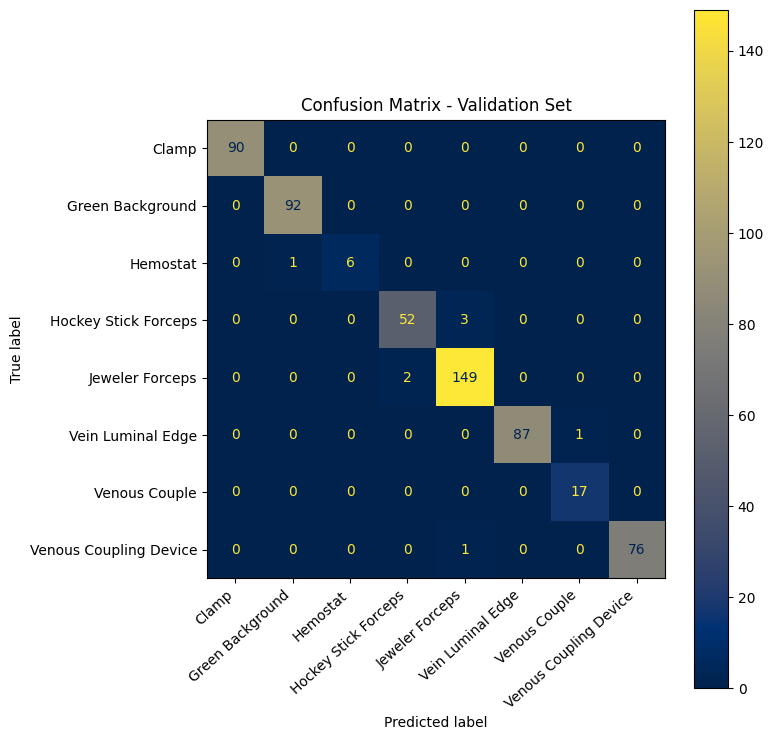

In [ ]:
yi, yhat, class_names = get_matched_predictions("valid")

cm = confusion_matrix(yi, yhat, labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.cividis, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right')
plt.title("Confusion Matrix - Validation Set")
plt.tight_layout()
plt.show()

loading annotations into memory...
Done (t=0.00s)
creating index...
index created!
Using a different number of positional encodings than DINOv2, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Using patch size 16 instead of 14, which means we're not loading DINOv2 backbone weights. This is not a problem if finetuning a pretrained RF-DETR model.
Loading pretrain weights


Matching (test): 100%|██████████| 42/42 [00:01<00:00, 28.57it/s]


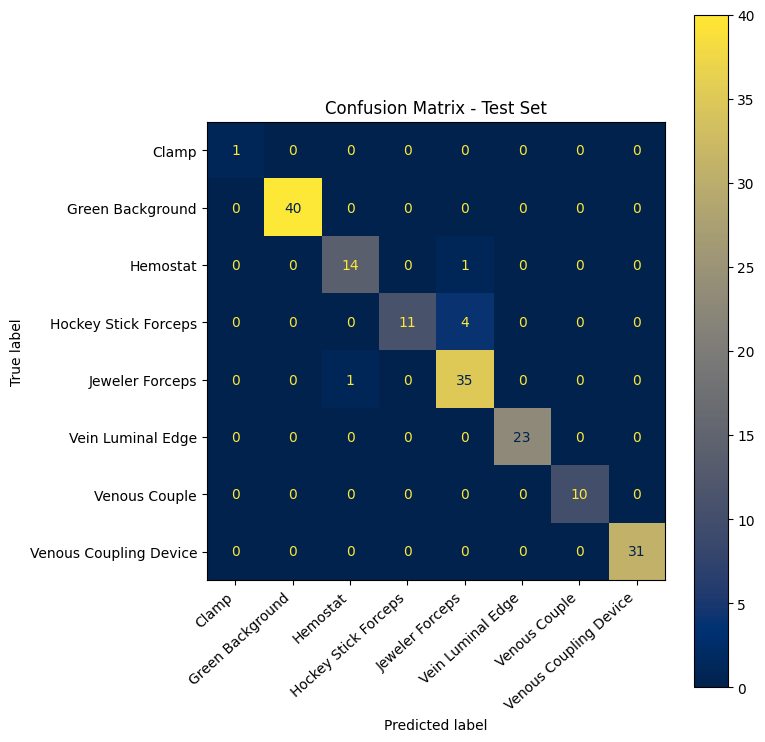

In [ ]:
yi, yhat, class_names = get_matched_predictions("test")

cm = confusion_matrix(yi, yhat, labels=class_names)
fig, ax = plt.subplots(figsize=(8, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.cividis, ax=ax)
ax.set_xticklabels(ax.get_xticklabels(), rotation=42, ha='right')
plt.title("Confusion Matrix - Test Set")
plt.tight_layout()
plt.show()